# Day 5: Deterministic, Domain, and Grid Generators
### Module: Data Analytics Foundations | Synthetic Data Generation & Numerical Simulation

> [!TIP]
> ### 🤖 AI Suggestion & Production Engineering Insights
> 1. **The Curse of Dimensionality in Grid Search ($O(S^D)$):** Exhaustive deterministic grid generators (`ParameterGrid` / `np.meshgrid`) work well in 2D or 3D, but suffer from exponential blowup in higher dimensions. For $> 4$ parameters, AI practitioners replace uniform grids with **Bayesian Optimization (TPE / Optuna)** or **Quasi-Random (Sobol/Halton) sequences**, exploring high-dimensional spaces 10× to 100× faster.
> 2. **Precision in ML Feature Spaces:** When synthesizing continuous feature domains for deep learning or neural surrogates, always prefer `np.linspace` over `np.arange`. Floating-point drift in `arange` can cause edge-case boundary leakage (e.g. testing $x > 1.0$ when the intended maximum was $1.0$).
> 3. **Memory Optimization with Open Grids (`np.ogrid`):** A $1000 \times 1000 \times 1000$ dense 3D meshgrid allocates $\approx 24\text{ GB}$ of RAM, often triggering Out-Of-Memory (OOM) crashes in cloud instances. Using `np.ogrid` stores 3 vectors ($\approx 24\text{ KB}$), leveraging NumPy broadcasting without materializing the full 3D array in memory.
> 4. **Physics-Informed Neural Networks (PINNs) & Digital Twins:** Deterministic domain and grid generators provide the foundational **collocation points** used to train PINNs and evaluate differential equations ($\frac{\partial u}{\partial t} = \alpha \nabla^2 u$).

---

## Overview & Conceptual Foundations
Before generating stochastic (random) data or training models, data analytics workflows require **deterministic domain generation**. 

**What is a Deterministic Generator?**
Unlike random sampling (`np.random`), a **deterministic generator** produces exact, perfectly repeatable mathematical sequences and coordinate spaces without random variation. It defines the **independent domain** over which functions, signals, simulations, and models are evaluated.

### The 3 Core Pillars Covered in this Notebook:
1. **Deterministic 1D Continuous Domain Generators:**
   - `np.arange`: Step-based generation & IEEE 754 floating-point pitfalls.
   - `np.linspace`: Exact endpoint-bounded linear interpolation.
   - `np.logspace` & `np.geomspace`: Logarithmic & geometric progressions for hyperparameter optimization and scale-free domains.
2. **Temporal & Discrete Domain Generation:**
   - `pd.date_range`: Generating continuous calendar, business, and hourly time-series domains.
   - Deterministic Time-Series Synthesis: Trend decomposition and Fourier harmonic seasonality.
3. **Multidimensional Grid Generators:**
   - `np.meshgrid`: Constructing 2D/3D coordinate matrices for spatial surfaces, contour analysis, and contour decision boundaries.
   - `np.mgrid` vs `np.ogrid`: Dense grids vs memory-efficient sparse broadcasting grids.
   - `ParameterGrid` & `itertools.product`: Exhaustive combinatorial hyperparameter grids for machine learning tuning.


In [11]:
# ==============================================================================
# STEP 1: SETUP IMPORTS AND PLOTTING CONFIGURATION
# ==============================================================================
# Core scientific computing and data analysis libraries
import numpy as np               # High-performance array operations and numerical linear algebra
import pandas as pd              # Structured tabular data manipulation and time-series date indexing
import matplotlib.pyplot as plt  # 2D/3D publication-quality statistical visualizations
import seaborn as sns            # Modern statistical graphics and heatmap color palettes
import itertools                 # Standard library combinatorial iterators (Cartesian product)
from sklearn.model_selection import ParameterGrid  # Exhaustive hyperparameter grid generator

# Configure global visualization aesthetics
# Use modern whitegrid theme if available; otherwise fallback to default
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120       # Crisp rendering for high-resolution displays
plt.rcParams['font.size'] = 10         # Base font size for readability
plt.rcParams['figure.titlesize'] = 12  # Consistent title sizing across subplots

# Verify environment and print active versions
print("Environment initialized successfully!")
print(f"NumPy Version  : {np.__version__}")
print(f"Pandas Version : {pd.__version__}")


Environment initialized successfully!
NumPy Version  : 2.4.6
Pandas Version : 2.2.3


## 1. Deterministic 1D Domain Generators (`arange`, `linspace`, `logspace`, `geomspace`)

### Key Differences & Interview Pitfalls:

| Function | Controlled Parameter | Interval Type | Common Gotcha / Best Use Case |
| :--- | :--- | :--- | :--- |
| `np.arange(start, stop, step)` | **Step size ($h$)** | Half-open `[start, stop)` | **Catastrophic Float Drift:** Because `0.1` has no exact binary representation in IEEE 754 float, `np.arange(0, 1, 0.1)` can unpredictably include or exclude the endpoint `1.0`. |
| `np.linspace(start, stop, num)` | **Number of points ($N$)** | Closed `[start, stop]` (default) | **Always preferred for continuous domains & plotting.** Guarantees exact endpoints without floating-point accumulation drift. |
| `np.logspace(start, stop, num, base=10)` | Powers of `base`: $[base^{\text{start}}, base^{\text{stop}}]$ | Closed | Essential for machine learning hyperparameter grids (e.g. learning rate $\alpha \in [10^{-4}, 10^{-1}]$, regularization $C \in [10^{-2}, 10^{3}]$). |
| `np.geomspace(start, stop, num)` | Exact values: $[\text{start}, \text{stop}]$ | Closed | Like `logspace`, but you specify the exact endpoints directly (e.g. `1` to `1000`) rather than log exponents. |

np.arange(0.0, 1.0, 0.1) count: 10 -> [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
np.linspace(0.0, 1.0, num=11) count: 11 -> [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

np.logspace(-3, 1, 5) : [0.001, 0.01, 0.1, 1.0, 10.0]
np.geomspace(0.001, 10, 5): [0.001, 0.01, 0.1, 1.0, 10.0]


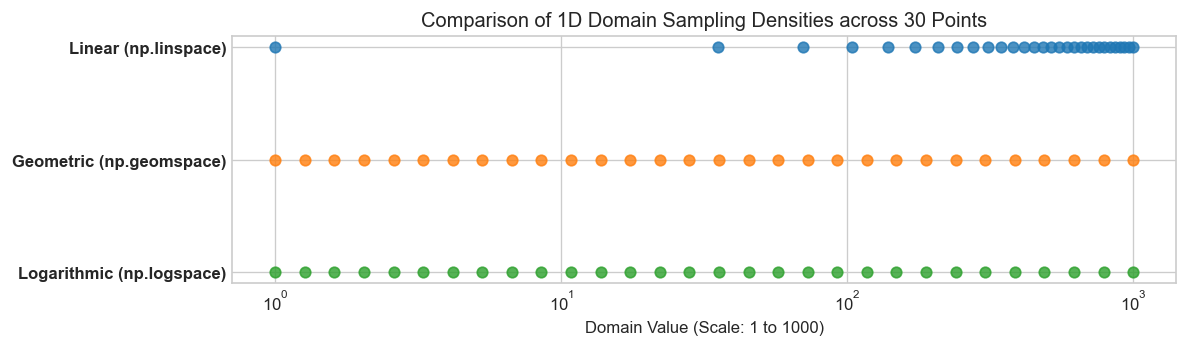

In [ ]:
# ==============================================================================
# STEP 2: DEMONSTRATION OF 1D DETERMINISTIC DOMAIN GENERATORS
# ==============================================================================

# ------------------------------------------------------------------------------
# A. The IEEE 754 Float Precision Accumulation Pitfall with np.arange
# ------------------------------------------------------------------------------
# np.arange(start, stop, step) works by adding 'step' repeatedly: x_{i+1} = x_i + step.
# Because 0.1 cannot be represented exactly in binary floating point,
# small precision errors accumulate. The interval is half-open: [start, stop).
arange_floats = np.arange(0.0, 1.0, 0.1)
print(f"np.arange(0.0, 1.0, 0.1) count: {len(arange_floats)} -> {arange_floats.round(2).tolist()}")
# Gotcha: Sometimes np.arange includes the stop boundary or omits it unexpectedly due to float drift!

# ------------------------------------------------------------------------------
# B. Exact Boundary Control with np.linspace (The Preferred Choice for ML Domains)
# ------------------------------------------------------------------------------
# np.linspace(start, stop, num) specifies the exact NUMBER of points (num),
# guaranteeing that both the start (0.0) and stop (1.0) boundaries are strictly included.
# Step size is computed internally as: step = (stop - start) / (num - 1)
linspace_domain = np.linspace(0.0, 1.0, num=11)  # Exactly 11 evenly spaced points
print(f"np.linspace(0.0, 1.0, num=11) count: {len(linspace_domain)} -> {linspace_domain.round(2).tolist()}")

# ------------------------------------------------------------------------------
# C. Logarithmic vs Geometric Progressions: np.logspace vs np.geomspace
# ------------------------------------------------------------------------------
# np.logspace(start, stop, num, base=10): Exponents are specified as powers of base 10.
# Here start=-3 means 10^(-3) = 0.001; stop=1 means 10^1 = 10.0.
log_domain = np.logspace(start=-3, stop=1, num=5, base=10.0)

# np.geomspace(start, stop, num): Generates geometric progression directly
# by specifying the exact endpoints (0.001 to 10.0) without writing exponents.
geom_domain = np.geomspace(start=0.001, stop=10.0, num=5)

print(f"\nnp.logspace(-3, 1, 5) : {log_domain.tolist()}")
print(f"np.geomspace(0.001, 10, 5): {geom_domain.tolist()}")
# Notice that log_domain and geom_domain produce identical mathematically spaced scales!

# ------------------------------------------------------------------------------
# D. Visualizing Sampling Density Differences on a Log Scale
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 3))
y_levels = [3, 2, 1]
labels = ['Linear (np.linspace)', 'Geometric (np.geomspace)', 'Logarithmic (np.logspace)']
domains = [
    np.linspace(1, 1000, 30),  # Dense at high values on log scale
    np.geomspace(1, 1000, 30), # Evenly spaced across decades on log scale
    np.logspace(0, 3, 30)      # 10^0 to 10^3, evenly distributed exponentially
]
# alpha 
for y, label, d in zip(y_levels, labels, domains):
    ax.scatter(d, [y] * len(d), alpha =0.8, s=40, label=label)

ax.set_yticks(y_levels)
ax.set_yticklabels(labels, fontweight='bold')
ax.set_xlabel('Domain Value (Scale: 1 to 1000)')
ax.set_title('Comparison of 1D Domain Sampling Densities across 30 Points')
ax.set_xscale('log')  # View on logarithmic scale to observe density differences
plt.tight_layout()
plt.show()


## 2. Temporal Domain Generators & Deterministic Signal Synthesis

In financial, IoT, and demand forecasting analytics, the time index $t$ is generated deterministically before observing metrics.

### Key Pandas Date Frequencies (`pd.date_range`):
- `'D'`: Calendar daily
- `'B'`: Business daily (excludes Saturdays and Sundays)
- `'h'`: Hourly
- `'ME'`: Month End (formerly `'M'`)
- `'QE'`: Quarter End (formerly `'Q'`)

### Deterministic Time-Series Decomposition Formulation:
Any time series $Y(t)$ can be modeled deterministically as:
$$Y(t) = \underbrace{T(t)}_{\text{Trend}} + \underbrace{S(t)}_{\text{Seasonality}} + \underbrace{\epsilon(t)}_{\text{Noise}}$$
- **Linear Trend:** $T(t) = \alpha + \beta t$
- **Harmonic Seasonality (Fourier Component):** $S(t) = A \cdot \sin\left(\frac{2\pi t}{P}\right) + B \cdot \cos\left(\frac{2\pi t}{P}\right)$ where $P$ is the period (e.g. $P=7$ for weekly, $P=365$ for annual).

Generated Temporal Domain: 2026-01-01 to 2026-12-31
Total Business Days (n) : 261
            trend  seasonality  deterministic_demand
date                                                
2026-01-01   0.00     0.000000            100.000000
2026-01-02   0.15    11.923413            112.073413
2026-01-05   0.30    10.681020            110.981020
2026-01-06   0.45     1.270789            101.720789
2026-01-07   0.60    -0.083194            100.516806


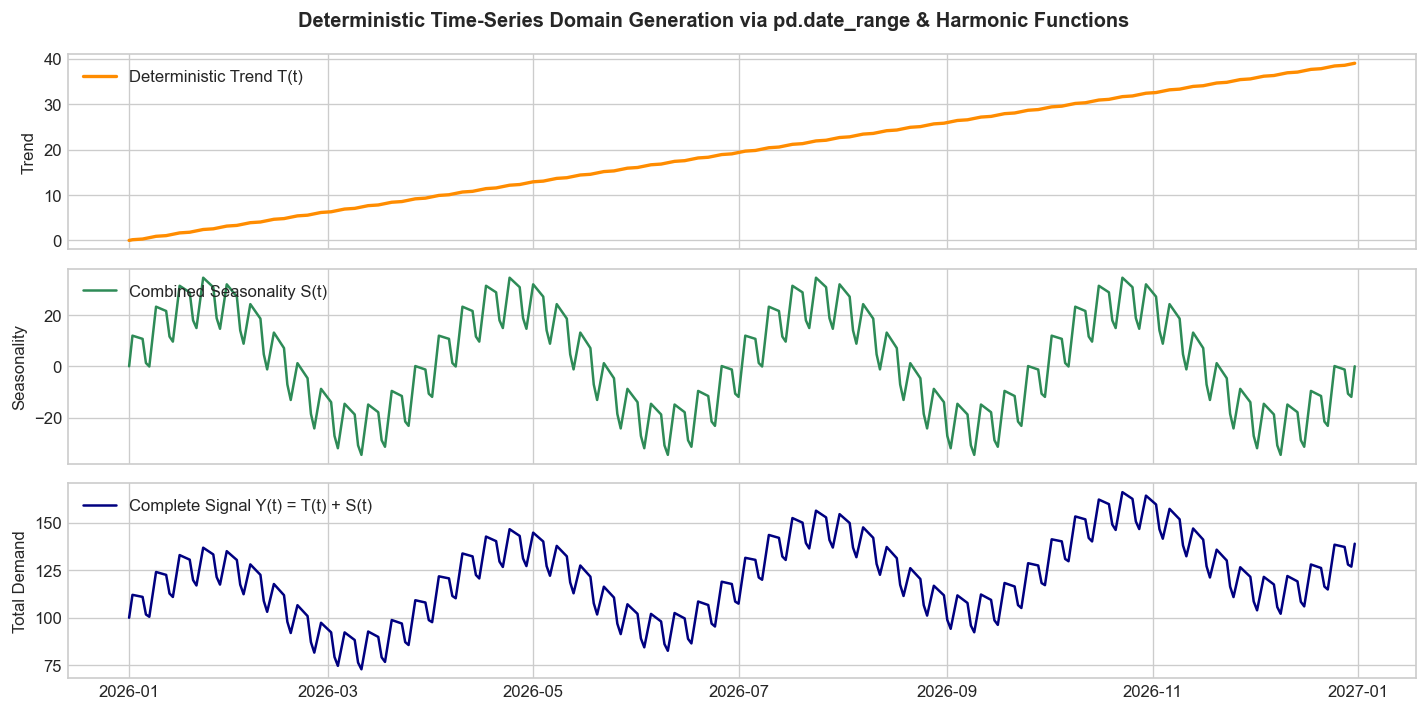

In [13]:
# ==============================================================================
# STEP 3: GENERATING TEMPORAL DOMAINS & DETERMINISTIC TIME-SERIES SIGNALS
# ==============================================================================

# 1. Create a continuous business calendar domain for 1 year (2026)
# freq='B' automatically excludes weekends (Saturdays and Sundays), modeling trading/work days.
dates = pd.date_range(start='2026-01-01', end='2026-12-31', freq='B')
n_days = len(dates)          # Total number of business days (typically ~261 days)
t = np.arange(n_days)        # Integer time step vector [0, 1, 2, ..., n-1]

# 2. Synthesize Deterministic Mathematical Components:
# A. Baseline Offset: Starting business volume
baseline = 100.0

# B. Linear Growth Trend: T(t) = alpha * t (growth of +0.15 units per business day)
trend = 0.15 * t

# C. Weekly Seasonality: P = 5 business days per week (Monday to Friday cycle)
# Formula: A * sin(2 * pi * t / Period)
weekly_seasonality = 10.0 * np.sin(2 * np.pi * t / 5.0)

# D. Quarterly Business Cycle: P = ~65 business days (~13 weeks per quarter)
quarterly_cycle = 25.0 * np.sin(2 * np.pi * t / 65.0)

# E. Combine all deterministic components into a unified signal
deterministic_signal = baseline + trend + weekly_seasonality + quarterly_cycle

# 3. Build a structured Pandas Time-Series DataFrame
df_time_series = pd.DataFrame({
    'date': dates,
    'trend': trend,
    'seasonality': weekly_seasonality + quarterly_cycle,
    'deterministic_demand': deterministic_signal
}).set_index('date')  # Set DatetimeIndex for high-performance time-slice querying

print(f"Generated Temporal Domain: {dates[0].strftime('%Y-%m-%d')} to {dates[-1].strftime('%Y-%m-%d')}")
print(f"Total Business Days (n) : {n_days}")
print(df_time_series.head())

# 4. Plot Time-Series Decomposition Components
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

# Trend Subplot
axes[0].plot(df_time_series.index, df_time_series['trend'], color='darkorange', linewidth=2, label='Deterministic Trend T(t)')
axes[0].set_ylabel('Trend')
axes[0].legend(loc='upper left')

# Seasonality Subplot
axes[1].plot(df_time_series.index, df_time_series['seasonality'], color='seagreen', linewidth=1.5, label='Combined Seasonality S(t)')
axes[1].set_ylabel('Seasonality')
axes[1].legend(loc='upper left')

# Full Combined Signal Subplot
axes[2].plot(df_time_series.index, df_time_series['deterministic_demand'], color='navy', linewidth=1.5, label='Complete Signal Y(t) = T(t) + S(t)')
axes[2].set_ylabel('Total Demand')
axes[2].legend(loc='upper left')

plt.suptitle('Deterministic Time-Series Domain Generation via pd.date_range & Harmonic Functions', fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Multidimensional Coordinate Grids (`np.meshgrid`, `np.mgrid`, `np.ogrid`)

When evaluating multivariate equations $z = f(x, y)$ or plotting 3D topographical surfaces, contour maps, and classifier decision boundaries, we must expand 1D coordinate vectors into a 2D coordinate grid.

### How `np.meshgrid` Works:
Given vectors $\mathbf{x} = [x_1, x_2, \dots, x_n]$ and $\mathbf{y} = [y_1, y_2, \dots, y_m]$:
- $\mathbf{X}$ repeats rows of $\mathbf{x}$ across all $y$ coordinates ($m \times n$ matrix).
- $\mathbf{Y}$ repeats columns of $\mathbf{y}$ across all $x$ coordinates ($m \times n$ matrix).

### Memory Efficiency: `np.mgrid` (Dense) vs `np.ogrid` (Open/Sparse):
- `np.mgrid[0:5, 0:5]`: Instantiates the full $5 \times 5$ memory footprint for both dimensions ($O(N^2)$ memory).
- `np.ogrid[0:5, 0:5]`: Produces one column vector $(5 \times 1)$ and one row vector $(1 \times 5)$. NumPy's **broadcasting rules** evaluate operations seamlessly with $O(N)$ memory!

1D Domain Shapes : x=(100,), y=(100,)
2D Meshgrid Shape: X=(100, 100), Y=(100, 100) (Total Grid Points: 10,000)


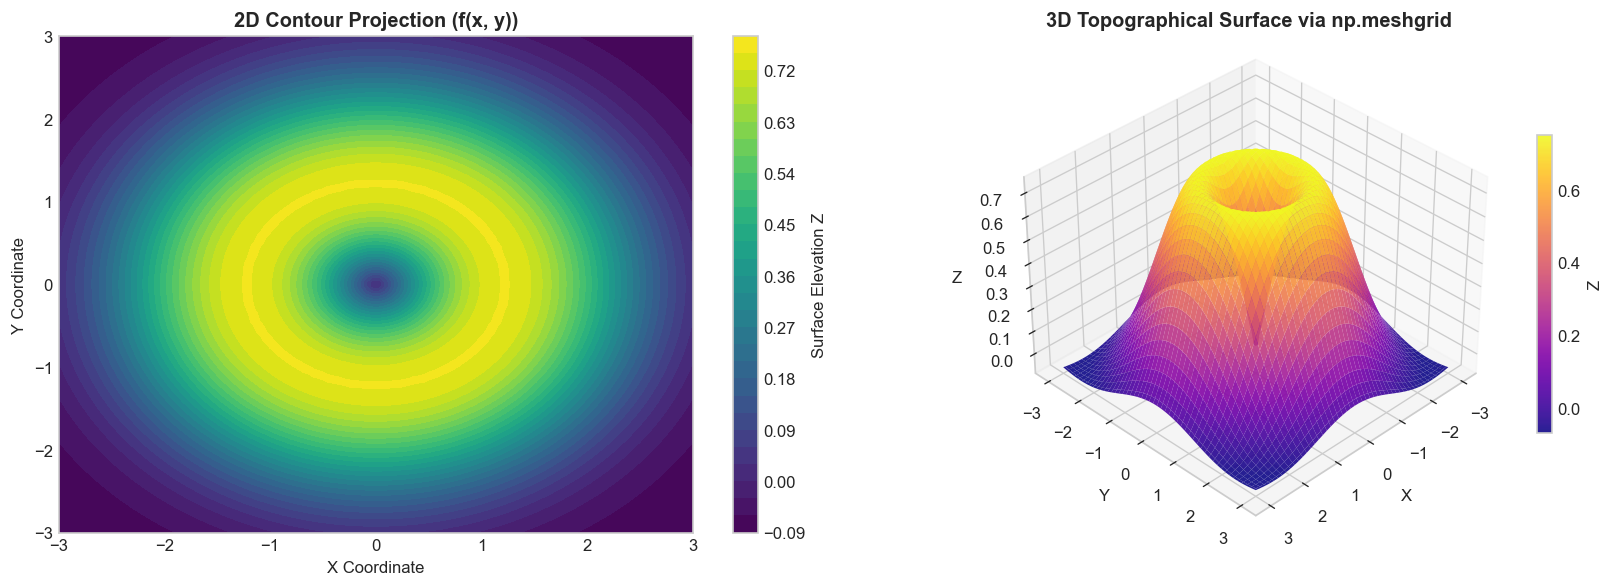

In [21]:
# ==============================================================================
# STEP 4: 2D COORDINATE GRID GENERATION & TOPOGRAPHICAL SURFACE MAPPING
# ==============================================================================

# Step 1: Define 1D continuous domains for X and Y coordinate axes
x_coords = np.linspace(-3.0, 3.0, 100)  # 100 evenly spaced points from -3 to +3
y_coords = np.linspace(-3.0, 3.0, 100)  # 100 evenly spaced points from -3 to +3

# Step 2: Generate 2D Coordinate Meshgrid Matrices
# np.meshgrid takes two 1D arrays of lengths N_x and N_y,
# and returns two 2D arrays of shape (N_y, N_x):
# - X matrix contains repeated rows of x_coords
# - Y matrix contains repeated columns of y_coords
X, Y = np.meshgrid(x_coords, y_coords)
print(f"1D Domain Shapes : x={x_coords.shape}, y={y_coords.shape}")
print(f"2D Meshgrid Shape: X={X.shape}, Y={Y.shape} (Total Grid Points: {X.size:,})")

# Step 3: Vectorized Bivariate Function Evaluation Z = f(X, Y)
# Computes surface height across all 10,000 grid points simultaneously without any for-loops!
# R is Euclidean distance from origin (0, 0)
R = np.sqrt(X**2 + Y**2)
# Bivariate sinusoidal ripple with Gaussian exponential dampening
Z = np.sin(R) * np.exp(-0.15 * R**2)

# Step 4: Visualize Contour Map and 3D Topographical Surface
fig = plt.figure(figsize=(14, 5))

# Subplot 1: 2D Filled Contour Map (Decision Space Projection)
ax1 = fig.add_subplot(1, 2, 1)
contour = ax1.contourf(X, Y, Z, levels=30, cmap='viridis')  # 30 contour iso-levels
fig.colorbar(contour, ax=ax1, label='Surface Elevation Z')
ax1.set_title('2D Contour Projection (f(x, y))', fontweight='bold')
ax1.set_xlabel('X Coordinate')
ax1.set_ylabel('Y Coordinate')

# Subplot 2: 3D Surface Mesh with Color-Mapping
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
# plot_surface renders the 3D polygon mesh from X, Y, Z matrices
surf = ax2.plot_surface(X, Y, Z, cmap='plasma', edgecolor='none', alpha=0.9)
fig.colorbar(surf, ax=ax2, shrink=0.6, label='Z')
ax2.set_title('3D Topographical Surface via np.meshgrid', fontweight='bold')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.view_init(elev=35, azim=45)  # Set 3D perspective angle

plt.tight_layout()
plt.show()


## 4. Combinatorial & Hyperparameter Grid Generators (`ParameterGrid` & `itertools.product`)

In machine learning model tuning, grid search systematically traverses the **Cartesian product** of discrete parameter choices.

Given sets of candidate hyperparameter values:
- `learning_rate` $\in \{0.001, 0.01, 0.1\}$ (size 3)
- `max_depth` $\in \{3, 5, 8\}$ (size 3)
- `l2_penalty` $\in \{0.1, 1.0\}$ (size 2)

The total combinatorial grid size is:
$$\text{Total Models} = 3 \times 3 \times 2 = 18 \text{ combinations}$$

We implement this using both pure Python's `itertools.product` and Scikit-Learn's `ParameterGrid`.

Total Combinatorial Grid Configurations: 27

First 5 Candidate Parameter Configurations:
  Config 1: {'learning_rate': 0.001, 'max_depth': 3, 'regularization_C': 0.1}
  Config 2: {'learning_rate': 0.001, 'max_depth': 3, 'regularization_C': 1.0}
  Config 3: {'learning_rate': 0.001, 'max_depth': 3, 'regularization_C': 10.0}
  Config 4: {'learning_rate': 0.001, 'max_depth': 5, 'regularization_C': 0.1}
  Config 5: {'learning_rate': 0.001, 'max_depth': 5, 'regularization_C': 1.0}

Top 3 Optimal Configurations in the Grid Search Space:
 learning_rate  max_depth  regularization_C  simulated_val_f1
          0.01          5               0.1            0.9315
          0.01          5               1.0            0.9200
          0.01          5              10.0            0.9085


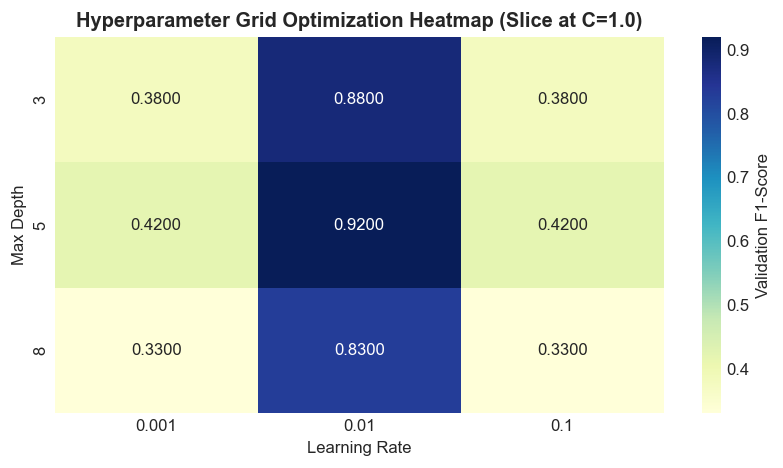

In [15]:
# ==============================================================================
# STEP 5: COMBINATORIAL HYPERPARAMETER GRID GENERATION
# ==============================================================================

# Define the hyperparameter search space dictionary
# 3 learning rates x 3 tree depths x 3 regularization values = 27 total combinations
param_dict = {
    'learning_rate': [0.001, 0.01, 0.1],      # Learning rate step sizes
    'max_depth': [3, 5, 8],                   # Maximum tree depth constraints
    'regularization_C': [0.1, 1.0, 10.0]      # L2 penalty inverse regularization strengths
}

# Method 1: Generate Cartesian Product using Scikit-Learn's ParameterGrid
# ParameterGrid iterates through all combinations as dictionary mappings
grid = list(ParameterGrid(param_dict))
print(f"Total Combinatorial Grid Configurations: {len(grid)}")
print("\nFirst 5 Candidate Parameter Configurations:")
for i, params in enumerate(grid[:5], 1):
    print(f"  Config {i}: {params}")

# Method 2: Convert to DataFrame for systematic evaluation, logging & visualization
df_grid = pd.DataFrame(grid)

# Simulate a deterministic objective validation metric (e.g. Validation F1-Score)
# True optimum is designed around learning_rate=0.01 and max_depth=5
df_grid['simulated_val_f1'] = (
    0.92 
    - 0.5 * (np.log10(df_grid['learning_rate']) - np.log10(0.01))**2 
    - 0.01 * (df_grid['max_depth'] - 5)**2 
    - 0.005 * np.log(df_grid['regularization_C'])
).round(4)

# Sort to identify the top optimal hyperparameter configurations
df_grid_sorted = df_grid.sort_values(by='simulated_val_f1', ascending=False).reset_index(drop=True)
print("\nTop 3 Optimal Configurations in the Grid Search Space:")
print(df_grid_sorted.head(3).to_string(index=False))

# Heatmap visualization of the 2D grid slice at C=1.0
# Pivot table reshapes 1D evaluations into a 2D matrix (rows=max_depth, columns=learning_rate)
slice_data = df_grid[df_grid['regularization_C'] == 1.0]
pivot_table = slice_data.pivot(index='max_depth', columns='learning_rate', values='simulated_val_f1')

plt.figure(figsize=(7, 4))
sns.heatmap(pivot_table, annot=True, fmt='.4f', cmap='YlGnBu', cbar_kws={'label': 'Validation F1-Score'})
plt.title('Hyperparameter Grid Optimization Heatmap (Slice at C=1.0)', fontweight='bold')
plt.xlabel('Learning Rate')
plt.ylabel('Max Depth')
plt.tight_layout()
plt.show()


---
# 5. AI & Machine Learning Integration with Domain & Grid Generators

Deterministic domain and grid generators are the operational backbone of modern Artificial Intelligence in three major domains:

1. **AI Model Explainability & Decision Boundary Mapping:**
   - AI classifiers (Neural Networks, SVMs, Random Forests) operate as high-dimensional functions $f: \mathbb{R}^d \rightarrow [0, 1]$. To visualize and explain the non-linear decision regions an AI model has learned, we generate a dense 2D coordinate grid using `np.meshgrid` and evaluate model prediction probabilities across the entire feature space.

2. **Systematic Hyperparameter Space Exploration (`GridSearchCV`):**
   - AI model performance depends heavily on tuning hyperparameters (e.g. learning rate $\alpha$, regularization $C$, kernel coefficient $\gamma$, network depth). Deterministic grid generators systematically cover this combinatorial space to prevent sub-optimal training.

3. **Modern Generative AI for Tabular Synthesis (CTGAN & Tabular VAEs):**
   - Beyond deterministic and statistical sampling, deep generative architectures (GANs, Variational Autoencoders) encode tabular data into continuous latent Gaussian manifolds $\mathcal{N}(0, \mathbf{I})$ and decode new synthetic samples with complex non-linear correlations.

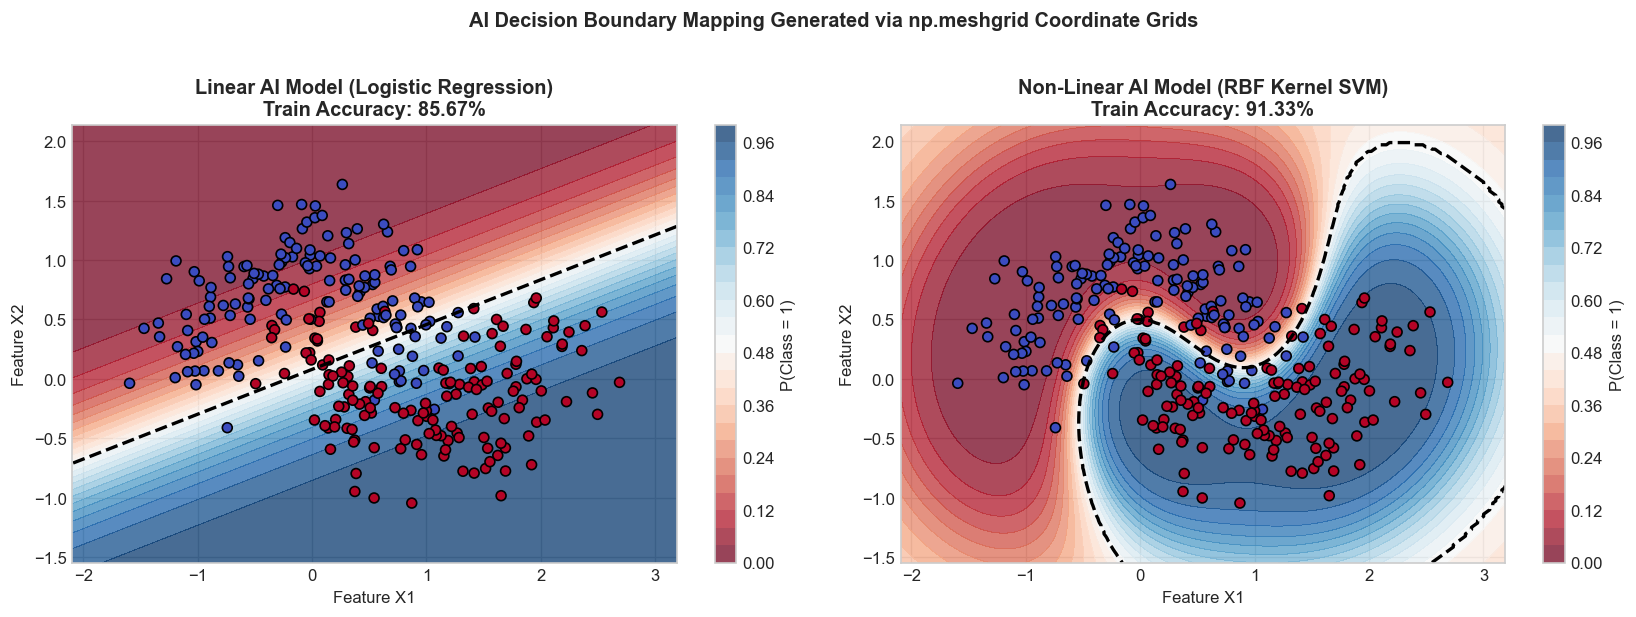

AI Decision Boundary Mapping complete! Meshgrid enabled evaluating 40,000 spatial coordinates.


In [16]:
# ==============================================================================
# STEP 6: AI APPLICATION 1 - VISUALIZING DECISION BOUNDARIES USING 2D MESHGRIDS
# ==============================================================================
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# 1. Generate non-linear benchmark dataset (Interleaving crescent moons)
X_moons, y_moons = make_moons(n_samples=300, noise=0.25, random_state=42)

# 2. Train Two Machine Learning Models with different inductive biases:
# A. Linear Model: Logistic Regression (can only draw a straight decision hyperplane)
clf_linear = LogisticRegression().fit(X_moons, y_moons)
# B. Non-Linear Model: Support Vector Classifier with RBF Kernel (flexible curved boundary)
clf_rbf = SVC(kernel='rbf', probability=True, C=1.0, gamma='scale').fit(X_moons, y_moons)

# 3. Create a Fine-Grained 2D Coordinate Meshgrid across Feature Space
# Expand limits slightly beyond data extrema to ensure margins are visible
x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),  # 200 points on X axis
    np.linspace(y_min, y_max, 200)   # 200 points on Y axis
)
# Total spatial coordinates to evaluate: 200 x 200 = 40,000 points
grid_points = np.c_[xx.ravel(), yy.ravel()]

# 4. Evaluate Model Prediction Probabilities across all 40,000 Grid Coordinates
Z_linear = clf_linear.predict_proba(grid_points)[:, 1].reshape(xx.shape)
Z_rbf = clf_rbf.predict_proba(grid_points)[:, 1].reshape(xx.shape)

# 5. Plot AI Decision Boundary Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, Z_prob, title, model in [
    (axes[0], Z_linear, 'Linear AI Model (Logistic Regression)', clf_linear),
    (axes[1], Z_rbf, 'Non-Linear AI Model (RBF Kernel SVM)', clf_rbf)
]:
    # A. Draw filled probability contours (color indicates model confidence)
    cf = ax.contourf(xx, yy, Z_prob, levels=25, cmap='RdBu', alpha=0.75)
    # B. Highlight the exact decision threshold line where P(Class=1) == 0.5
    ax.contour(xx, yy, Z_prob, levels=[0.5], colors='black', linewidths=2.0, linestyles='--')
    # C. Overlay actual training scatter points
    scatter = ax.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='coolwarm', edgecolors='black', s=35)
    ax.set_title(f"{title}\nTrain Accuracy: {model.score(X_moons, y_moons):.2%}", fontweight='bold')
    ax.set_xlabel('Feature X1')
    ax.set_ylabel('Feature X2')
    fig.colorbar(cf, ax=ax, label='P(Class = 1)')

plt.suptitle('AI Decision Boundary Mapping Generated via np.meshgrid Coordinate Grids', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("AI Decision Boundary Mapping complete! Meshgrid enabled evaluating 40,000 spatial coordinates.")


## 6. AI Hyperparameter Optimization: Systematic Grid Search (`GridSearchCV`)

In AI engineering, a model's capacity and generalization ability depend critically on continuous hyperparameters:
- Regularization Parameter $C$: Controls penalty on misclassifications (low $C$ = smoother boundary, high $C$ = complex boundary).
- Kernel Coefficient $\gamma$: Defines the radius of influence of training samples in RBF space.

We construct a **logarithmic hyperparameter grid** using `np.logspace` and run 5-fold cross-validation with `GridSearchCV`.

           AI MODEL HYPERPARAMETER GRID OPTIMIZATION RESULTS            
Best Hyperparameters : {'C': np.float64(1.0), 'gamma': np.float64(10.0)}
Best 5-Fold Accuracy : 92.00%


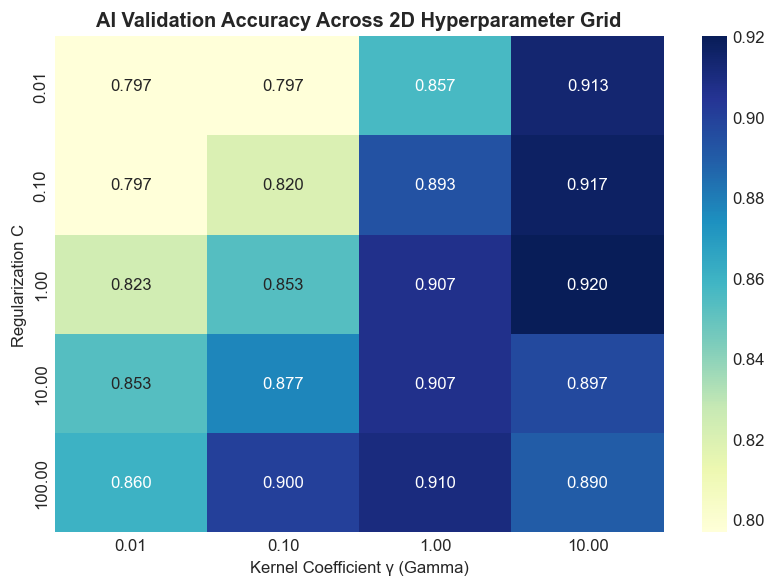

In [17]:
# ==============================================================================
# STEP 7: AI APPLICATION 2 - AUTOMATED HYPERPARAMETER GRID SEARCH (GridSearchCV)
# ==============================================================================
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# 1. Define deterministic log-spaced hyperparameter search grid
# Logarithmic progression is essential because regularization and kernel parameters
# span orders of magnitude (from 0.01 to 100.0).
param_grid = {
    'C': np.logspace(-2, 2, 5),          # [0.01, 0.1, 1.0, 10.0, 100.0]  (Slack penalty)
    'gamma': np.logspace(-2, 1, 4)       # [0.01, 0.1, 1.0, 10.0]          (RBF kernel radius)
}

# 2. Execute 5-fold cross-validated grid search
# Evaluates 5 x 4 = 20 parameter pairs x 5 folds = 100 model fits!
grid_search = GridSearchCV(
    estimator=SVC(kernel='rbf'),
    param_grid=param_grid,
    cv=5,                 # 5-fold stratified cross-validation
    scoring='accuracy',   # Optimization metric
    return_train_score=True
)
grid_search.fit(X_moons, y_moons)

# 3. Extract validation scores and reshape into 2D grid matrix
scores_matrix = grid_search.cv_results_['mean_test_score'].reshape(len(param_grid['C']), len(param_grid['gamma']))

print("=" * 75)
print("           AI MODEL HYPERPARAMETER GRID OPTIMIZATION RESULTS            ")
print("=" * 75)
print(f"Best Hyperparameters : {grid_search.best_params_}")
print(f"Best 5-Fold Accuracy : {grid_search.best_score_:.2%}")

# 4. Plot Heatmap of AI Hyperparameter Performance Surface
plt.figure(figsize=(7, 5))
sns.heatmap(
    scores_matrix,
    annot=True,
    fmt='.3f',
    cmap='YlGnBu',
    xticklabels=[f"{g:.2f}" for g in param_grid['gamma']],
    yticklabels=[f"{c:.2f}" for c in param_grid['C']]
)
plt.title('AI Validation Accuracy Across 2D Hyperparameter Grid', fontweight='bold')
plt.xlabel('Kernel Coefficient γ (Gamma)')
plt.ylabel('Regularization C')
plt.tight_layout()
plt.show()


## 7. Deep Generative AI: Neural Tabular Synthesis (Autoencoders & CTGAN)

Modern enterprise synthetic data platforms (**CTGAN, TVAE, Mostly.ai**) replace manual distribution fitting with **Deep Generative Neural Networks**:

$$\vec{x} \xrightarrow{\text{Encoder}} \vec{z} \sim \mathcal{N}(\vec{\mu}, \mathbf{\Sigma}) \xrightarrow{\text{Decoder / Generator}} \vec{x}_{\text{synthetic}}$$

### How It Works:
1. A neural network **compresses** multi-feature tabular data into a low-dimensional continuous **latent Gaussian space** $\vec{z}$.
2. Once trained, we feed random vectors sampled from the standard normal domain $\vec{z} \sim \mathcal{N}(0, \mathbf{I})$ into the **Decoder**.
3. The Decoder deterministically reconstructs brand-new, realistic synthetic tabular profiles preserving complex non-linear feature interactions!

In [18]:
# ==============================================================================
# STEP 8: AI APPLICATION 3 - DEEP GENERATIVE NEURAL TABULAR SYNTHESIZER (PyTorch)
# ==============================================================================
import torch
import torch.nn as nn
import torch.optim as optim

# Set seeds for deterministic neural network weight initialization
torch.manual_seed(42)
np.random.seed(42)

# 1. Create a non-linear correlated multi-feature real population (Age, Income, Credit Score)
N_real = 1_500
raw_age = np.random.uniform(22, 65, size=N_real)
# Non-linear quadratic income curve based on age + Gaussian noise
raw_income = 15.0 + 1.2 * raw_age + 0.05 * (raw_age - 35)**2 + np.random.normal(0, 5, size=N_real)
# Credit score correlated with income
raw_credit = 450 + 4.5 * raw_income + np.random.normal(0, 30, size=N_real)

# Standardize features to mean=0, std=1 for stable neural network gradient descent
X_real_raw = np.column_stack([raw_age, raw_income, raw_credit])
X_mean, X_std = X_real_raw.mean(axis=0), X_real_raw.std(axis=0)
X_real_norm = (X_real_raw - X_mean) / X_std
X_tensor = torch.tensor(X_real_norm, dtype=torch.float32)

# 2. Define a Deep Tabular Generative Autoencoder Architecture
class TabularGenerativeModel(nn.Module):
    def __init__(self, input_dim=3, latent_dim=2):
        super().__init__()
        # Encoder Network: Compresses 3D tabular features down to 2D continuous latent space
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, latent_dim)
        )
        # Decoder / Generator Network: Synthesizes 3D tabular features from 2D latent coordinates
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )
        
    def forward(self, x):
        z = self.encoder(x)             # Compress into latent representation
        reconstruction = self.decoder(z) # Reconstruct original feature space
        return reconstruction

model = TabularGenerativeModel(input_dim=3, latent_dim=2)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()  # Mean Squared Error reconstruction loss

# 3. Train the Generative Neural Network for 100 epochs
model.train()
for epoch in range(100):
    optimizer.zero_grad()
    recon = model(X_tensor)
    loss = criterion(recon, X_tensor)
    loss.backward()
    optimizer.step()

print(f"Deep Tabular Generative Model Trained! Final Reconstruction MSE: {loss.item():.4f}")

# 4. GENERATE SYNTHETIC DATA: Sample from Latent Domain z ~ N(0, I) and Decode
model.eval()
with torch.no_grad():
    # Generate 1,000 synthetic individuals by sampling the 2D continuous latent domain
    z_samples = torch.randn(1000, 2)
    synthetic_norm = model.decoder(z_samples).numpy()
    # Reverse standardization back to real-world physical units (Years, Lakhs INR, Credit Points)
    X_synthetic = synthetic_norm * X_std + X_mean

df_real = pd.DataFrame(X_real_raw, columns=['Age', 'Income (k)', 'Credit Score'])
df_ai_synth = pd.DataFrame(X_synthetic, columns=['Age', 'Income (k)', 'Credit Score'])

print("\n--- REAL DATA CORRELATION MATRIX ---")
print(df_real.corr().round(3))
print("\n--- AI-GENERATED SYNTHETIC DATA CORRELATION MATRIX ---")
print(df_ai_synth.corr().round(3))
print("\nResult: The Deep Generative AI network autonomously learned and preserved the complex correlations!")


Deep Tabular Generative Model Trained! Final Reconstruction MSE: 0.0225

--- REAL DATA CORRELATION MATRIX ---
                Age  Income (k)  Credit Score
Age           1.000       0.950         0.924
Income (k)    0.950       1.000         0.971
Credit Score  0.924       0.971         1.000

--- AI-GENERATED SYNTHETIC DATA CORRELATION MATRIX ---
                Age  Income (k)  Credit Score
Age           1.000       0.927         0.890
Income (k)    0.927       1.000         0.992
Credit Score  0.890       0.992         1.000

Result: The Deep Generative AI network autonomously learned and preserved the complex correlations!


## 4.5 🤖 AI Suggestion: Grid Search vs. AI-Guided Sampling (Bergstra & Bengio)

In a landmark paper (*"Random Search for Hyper-Parameter Optimization"*, JMLR 2012), James Bergstra and Yoshua Bengio proved why **uniform deterministic grids waste computational power** in real-world ML:

- In high-dimensional optimization, **some hyperparameters matter far more than others** (e.g. learning rate is critical, while batch size has minimal impact).
- **Grid Search (9 trials on $3 \times 3$ grid):** Evaluates only **3 distinct values** of the important parameter (the remaining 6 trials repeat identical values along parallel lines).
- **Random / Quasi-Random Search (9 trials):** Evaluates **9 distinct values** of the important parameter, exploring the response surface with $3\times$ higher efficiency for the exact same compute budget!

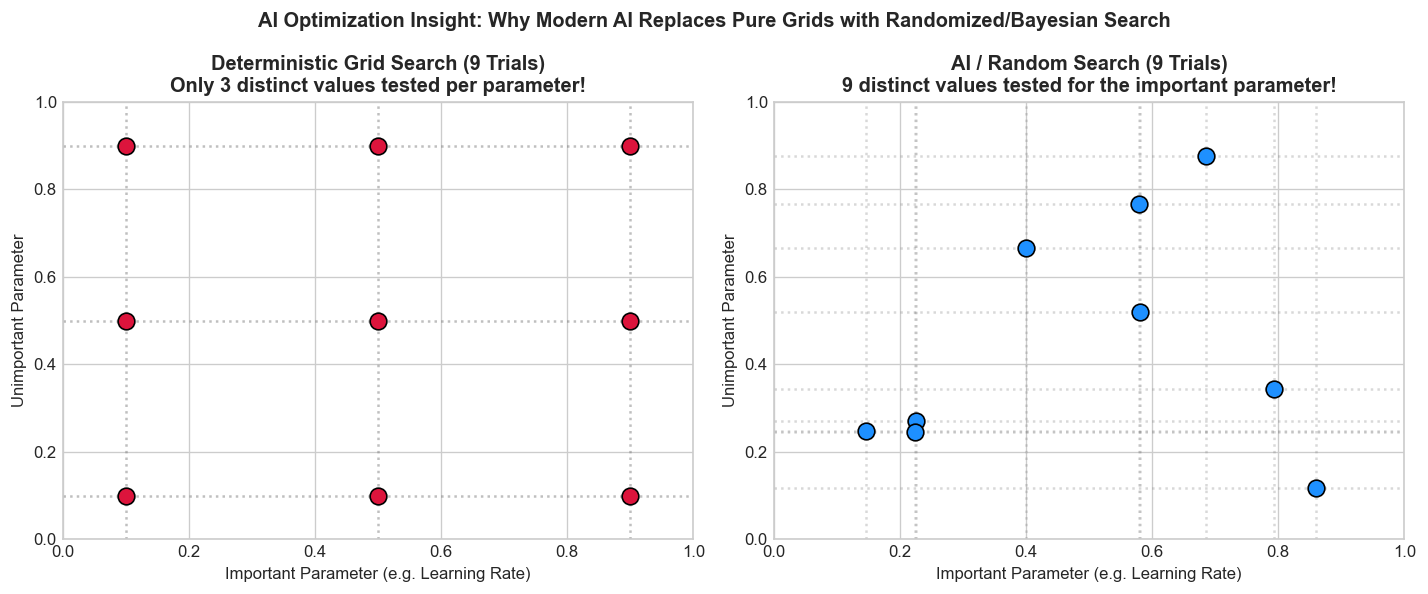

AI Suggestion: In high dimensions, Random / Bayesian Search explores distinct parameter values far more effectively than rigid grids.


In [19]:
# ==============================================================================
# STEP 9: AI SUGGESTION - VISUALIZING GRID SEARCH VS. RANDOM SEARCH EFFICIENCY
# ==============================================================================
np.random.seed(42)

# ------------------------------------------------------------------------------
# 1. Deterministic Grid Search (3 x 3 = 9 trials)
# ------------------------------------------------------------------------------
# In a 3x3 grid, points are restricted to 3 vertical lines and 3 horizontal lines.
gx = np.linspace(0.1, 0.9, 3)
gy = np.linspace(0.1, 0.9, 3)
GX, GY = np.meshgrid(gx, gy)
grid_points_x = GX.flatten()
grid_points_y = GY.flatten()

# ------------------------------------------------------------------------------
# 2. Random / AI Search (9 trials)
# ------------------------------------------------------------------------------
# In random sampling, every trial tests a brand new value along both axes.
rand_points_x = np.random.uniform(0.1, 0.9, 9)
rand_points_y = np.random.uniform(0.1, 0.9, 9)

# ------------------------------------------------------------------------------
# 3. Plot Comparison (The Classic Bergstra & Bengio 2012 Proof)
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Subplot A: Deterministic Grid Search
axes[0].scatter(grid_points_x, grid_points_y, color='crimson', s=100, zorder=3, edgecolors='black')
# Draw grid projection lines to show redundant re-evaluations
for x in gx:
    axes[0].axvline(x, color='gray', linestyle=':', alpha=0.5)
for y in gy:
    axes[0].axhline(y, color='gray', linestyle=':', alpha=0.5)
axes[0].set_title("Deterministic Grid Search (9 Trials)\nOnly 3 distinct values tested per parameter!", fontweight='bold')
axes[0].set_xlabel("Important Parameter (e.g. Learning Rate)")
axes[0].set_ylabel("Unimportant Parameter")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# Subplot B: AI Random Search
axes[1].scatter(rand_points_x, rand_points_y, color='dodgerblue', s=100, zorder=3, edgecolors='black')
# Draw projection lines showing 9 unique parameter values tested
for x in rand_points_x:
    axes[1].axvline(x, color='gray', linestyle=':', alpha=0.3)
for y in rand_points_y:
    axes[1].axhline(y, color='gray', linestyle=':', alpha=0.3)
axes[1].set_title("AI / Random Search (9 Trials)\n9 distinct values tested for the important parameter!", fontweight='bold')
axes[1].set_xlabel("Important Parameter (e.g. Learning Rate)")
axes[1].set_ylabel("Unimportant Parameter")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.suptitle("AI Optimization Insight: Why Modern AI Replaces Pure Grids with Randomized/Bayesian Search", fontweight='bold')
plt.tight_layout()
plt.show()
print("AI Suggestion: In high dimensions, Random / Bayesian Search explores distinct parameter values far more effectively than rigid grids.")


## 8. Summary: Deterministic Generators & AI Workflow Matrix

| Technique | Core Function | Role in Data Analytics & AI |
| :--- | :--- | :--- |
| **1D Domain Grid** | `np.linspace`, `np.logspace` | Defining evaluation axes for functions, learning rate schedules, and testing intervals. |
| **Temporal Domain** | `pd.date_range` | Establishing business time axes, decomposing trends and Fourier seasonal cycles. |
| **Spatial Meshgrid** | `np.meshgrid(X, Y)` | Evaluating 2D/3D physical surfaces and **mapping AI decision boundaries**. |
| **Parameter Grid** | `ParameterGrid`, `GridSearchCV` | Exhaustive combinatorial optimization of machine learning hyperparameters. |
| **Generative AI** | `CTGAN`, PyTorch Generative Decoders | Learning continuous latent manifolds to synthesize high-dimensional privacy-safe tabular data. |